# Why Correlation PCA for Return Matrices?

This notebook uses synthetic returns to explain why PCA is often applied to **standardized returns**, equivalently the **correlation matrix**, rather than directly to the raw covariance matrix.

The point is not that covariance PCA is mathematically wrong. Covariance PCA answers a different question:

$$
\text{Covariance PCA: find directions with largest data-variation.}
$$

If a few assets have extremely high idiosyncratic volatility, covariance PCA can put large weight on those assets even when they are not the cleanest representation of the common factor.

Correlation PCA first removes each asset's individual volatility scale:

$$
X_{ti}=\frac{R_{ti}-\bar R_i}{s_i},
$$

and then studies

$$
C_{\mathrm{corr}}=\frac{1}{T}X^\top X.
$$

This is usually more suitable when the goal is to study **co-movement structure** rather than raw volatility scale.


## Synthetic Data Generating Process

We simulate a one-factor return model:

$$
r_{ti}=\beta_i f_t+\sigma_i\epsilon_{ti},
$$

where

$$
f_t\sim N(0,1),\qquad \epsilon_{ti}\sim N(0,1).
$$

The cross-sectional profiles are fixed:

- $\beta_i$ is the true exposure of stock $i$ to the common factor;
- $\sigma_i$ is the idiosyncratic volatility of stock $i$.

We deliberately make a few stocks have huge idiosyncratic volatility. This lets us test whether covariance PCA is pulled toward those high-volatility names.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")


In [6]:
def center_columns(A):
    """Subtract each column's sample mean."""
    return A - A.mean(axis=0, keepdims=True)


def standardize_columns(A):
    """Center and scale each column to unit sample standard deviation."""
    X = center_columns(A)
    s = X.std(axis=0, ddof=0, keepdims=True)
    return X / s, s.ravel()


def top_eigenpair(C):
    """Return eigenvalues/eigenvectors of symmetric C in descending order."""
    vals, vecs = np.linalg.eigh(C)
    idx = np.argsort(vals)[::-1]
    return vals[idx], vecs[:, idx]


def align(u, v):
    """Absolute cosine similarity. Eigenvector signs are arbitrary."""
    u = np.asarray(u)
    v = np.asarray(v)
    return abs(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v)))


def effective_number(v):
    """
    Effective number of assets contributing to a unit loading vector.

    Let p_i = v_i^2. Since sum p_i = 1, the Herfindahl concentration is
    sum p_i^2 = sum v_i^4. Its inverse is the effective number.
    """
    v = np.asarray(v)
    v = v / np.linalg.norm(v)
    return 1.0 / np.sum(v**4)


def sample_covariance(A, center=True):
    X = center_columns(A) if center else A
    return X.T @ X / X.shape[0]


## Fixed Cross-Sectional Profiles

We set

$$
T=1000,\qquad N=80.
$$

The factor exposures $\beta_i$ are fixed but heterogeneous. Most idiosyncratic volatilities $\sigma_i$ are normal-sized, while three synthetic stocks have very large idiosyncratic volatility.


In [8]:
rng = np.random.default_rng(2026)

T = 1000
N = 80
n_trials = 100

names = np.array([f"Stock_{i:02d}" for i in range(1, N + 1)])

# Fixed beta profile: heterogeneous but realistic positive factor exposure.
beta = rng.uniform(0.5, 1.3, size=N)
beta[[5, 22, 57]] = [0.6, 1.2, 0.5]

# Fixed idiosyncratic volatility profile.
sigma = rng.uniform(0.35, 0.80, size=N)
high_vol_idx = np.array([7, 31, 64])
sigma[high_vol_idx] = np.array([8.0, 9.0, 10.0])

profile = pd.DataFrame({
    "stock": names,
    "beta": beta,
    "sigma": sigma,
    "is_huge_vol": False,
})
profile.loc[high_vol_idx, "is_huge_vol"] = True

profile.sort_values("sigma", ascending=False).head(8)


,stock,beta,sigma,is_huge_vol
64,Stock_65,1.223763,10.000000,True
31,Stock_32,1.199699,9.000000,True
7,Stock_08,0.641883,8.000000,True
50,Stock_51,0.997203,0.781316,False
12,Stock_13,1.008697,0.773954,False
10,Stock_11,1.273570,0.763279,False
17,Stock_18,0.771050,0.762768,False
70,Stock_71,0.953640,0.761505,False


## Population Directions

For raw returns,

$$
r_{ti}=\beta_i f_t+\sigma_i\epsilon_{ti},
$$

the common factor direction is $\beta$.

For standardized returns, each column is divided by its own total volatility. Since

$$
\mathrm{Var}(r_i)=\beta_i^2+\sigma_i^2,
$$

the common factor loading in standardized space is approximately

$$
\gamma_i=\frac{\beta_i}{\sqrt{\beta_i^2+\sigma_i^2}}.
$$

Therefore we compare covariance PC1 with $\beta$, and correlation PC1 with $\gamma$.


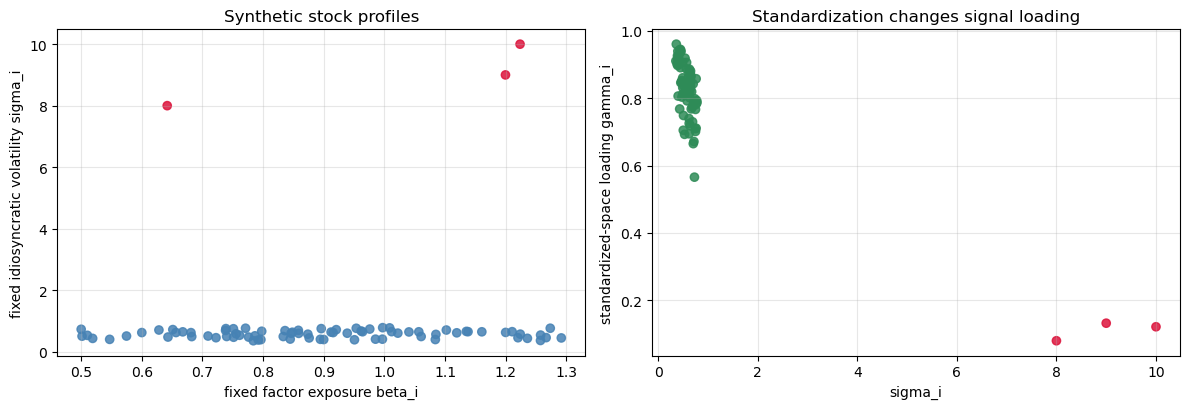

In [10]:
beta_dir = beta / np.linalg.norm(beta)
gamma = beta / np.sqrt(beta**2 + sigma**2)
gamma_dir = gamma / np.linalg.norm(gamma)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].scatter(beta, sigma, c=np.where(profile["is_huge_vol"], "crimson", "steelblue"), alpha=0.85)
axes[0].set_xlabel("fixed factor exposure beta_i")
axes[0].set_ylabel("fixed idiosyncratic volatility sigma_i")
axes[0].set_title("Synthetic stock profiles")
axes[0].grid(alpha=0.3)

axes[1].scatter(sigma, gamma, c=np.where(profile["is_huge_vol"], "crimson", "seagreen"), alpha=0.85)
axes[1].set_xlabel("sigma_i")
axes[1].set_ylabel("standardized-space loading gamma_i")
axes[1].set_title("Standardization changes signal loading")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## One Trial: Covariance PC1 vs Correlation PC1

We first inspect one simulated sample.

- Covariance matrix:

$$
C_{\mathrm{cov}}=\frac{1}{T}R^\top R.
$$

- Correlation matrix:

$$
C_{\mathrm{corr}}=\frac{1}{T}X^\top X,
\qquad X_{ti}=\frac{R_{ti}-\bar R_i}{s_i}.
$$


In [12]:
def simulate_returns(rng):
    f = rng.normal(0.0, 1.0, size=T)
    eps = rng.normal(0.0, 1.0, size=(T, N))
    R = f[:, None] * beta[None, :] + eps * sigma[None, :]
    return R

R = simulate_returns(rng)
X, sample_vol = standardize_columns(R)

C_cov = sample_covariance(R, center=True)
C_corr = X.T @ X / T

vals_cov, vecs_cov = top_eigenpair(C_cov)
vals_corr, vecs_corr = top_eigenpair(C_corr)

v_cov = vecs_cov[:, 0]
v_corr = vecs_corr[:, 0]

summary_one = pd.DataFrame({
    "method": ["Covariance PCA", "Correlation PCA"],
    "lambda_1": [vals_cov[0], vals_corr[0]],
    "alignment_with_true_direction": [align(v_cov, beta_dir), align(v_corr, gamma_dir)],
    "corr_abs_loading_with_sigma": [np.corrcoef(np.abs(v_cov), sigma)[0, 1], np.corrcoef(np.abs(v_corr), sigma)[0, 1]],
    "N_eff": [effective_number(v_cov), effective_number(v_corr)],
})
summary_one


,method,lambda_1,alignment_with_true_direction,corr_abs_loading_with_sigma,N_eff
0,Covariance PCA,108.574766,0.432791,0.680494,1.255886
1,Correlation PCA,53.686226,0.999871,-0.883436,74.769965


## Experiment 1: Does PC1 Loading Chase Volatility?

We compare $|v_{1,i}|$ with $\sigma_i$.

If covariance PCA is dominated by high-volatility names, then $|v_{1,i}|$ should be strongly related to $\sigma_i$ and the extreme-volatility stocks should have very large loadings.


The plot now reports the Pearson correlation and overlays a linear trend line, so we do not rely only on visual inspection of the scatter points.


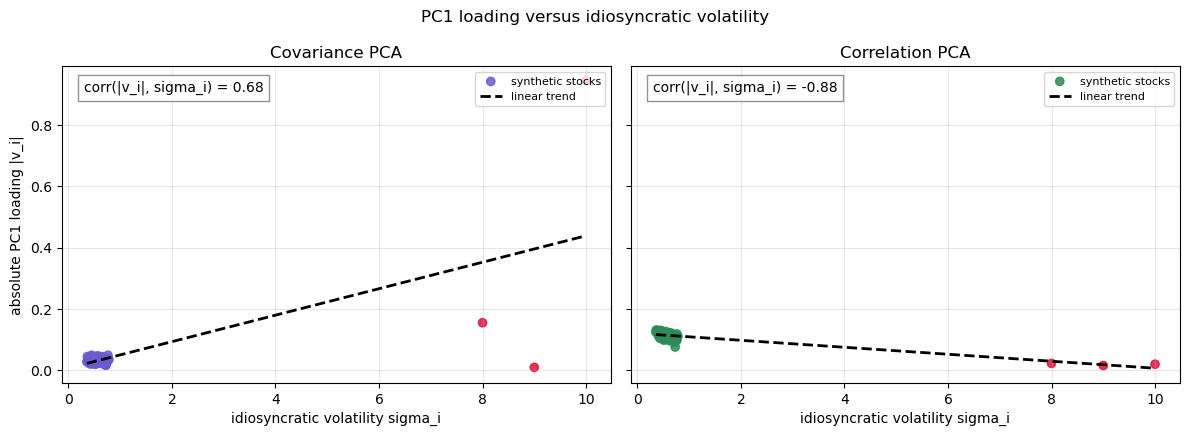

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)

for ax, v, title, color in [
    (axes[0], v_cov, "Covariance PCA", "slateblue"),
    (axes[1], v_corr, "Correlation PCA", "seagreen"),
]:
    abs_loading = np.abs(v)
    corr_value = np.corrcoef(abs_loading, sigma)[0, 1]

    ax.scatter(
        sigma,
        abs_loading,
        c=np.where(profile["is_huge_vol"], "crimson", color),
        alpha=0.85,
        label="synthetic stocks",
    )

    # Linear trend line makes the loading-volatility relationship visible.
    slope, intercept = np.polyfit(sigma, abs_loading, deg=1)
    x_grid = np.linspace(sigma.min(), sigma.max(), 200)
    ax.plot(
        x_grid,
        intercept + slope * x_grid,
        color="black",
        linestyle="--",
        linewidth=2,
        label="linear trend",
    )

    ax.text(
        0.04,
        0.92,
        f"corr(|v_i|, sigma_i) = {corr_value:.2f}",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85),
    )
    ax.set_xlabel("idiosyncratic volatility sigma_i")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("absolute PC1 loading |v_i|")
plt.suptitle("PC1 loading versus idiosyncratic volatility")
plt.tight_layout()
plt.show()


## Experiment 2: Top Loading Names

For each method, we list the synthetic stocks with the largest absolute PC1 loading.

This mimics what we would later do with real stocks: inspect which assets dominate a principal component.


The table includes the corresponding population target loading: covariance PCA is compared with the normalized beta direction, while correlation PCA is compared with the normalized standardized-space gamma direction.


In [22]:
def top_loading_table(v, true_dir, true_loading_name, top_n=12):
    idx = np.argsort(np.abs(v))[::-1][:top_n]
    return pd.DataFrame({
        "stock": names[idx],
        "pc1_loading": v[idx],
        "abs_pc1_loading": np.abs(v[idx]),
        true_loading_name: true_dir[idx],
        "beta": beta[idx],
        "sigma": sigma[idx],
        "is_huge_vol": profile["is_huge_vol"].to_numpy()[idx],
    })

cov_top = top_loading_table(v_cov, beta_dir, "true_cov_loading_beta_dir")
corr_top = top_loading_table(v_corr, gamma_dir, "true_corr_loading_gamma_dir")

print("Top loadings: covariance PCA")
display(cov_top)
print("Top loadings: correlation PCA")
display(corr_top)


Top loadings: covariance PCA


,stock,pc1_loading,abs_pc1_loading,true_cov_loading_beta_dir,beta,sigma,is_huge_vol
0,Stock_65,-0.944429,0.944429,0.148124,1.223763,10.000000,True
1,Stock_08,-0.154566,0.154566,0.077693,0.641883,8.000000,True
2,Stock_11,-0.048558,0.048558,0.154152,1.273570,0.763279,False
3,Stock_66,-0.048221,0.048221,0.156358,1.291789,0.447436,False
4,Stock_07,-0.046297,0.046297,0.148166,1.224115,0.571167,False
5,Stock_12,-0.045469,0.045469,0.149591,1.235880,0.434716,False
6,Stock_74,-0.044958,0.044958,0.153330,1.266772,0.457435,False
7,Stock_78,-0.044936,0.044936,0.152225,1.257650,0.540326,False
8,Stock_36,-0.044109,0.044109,0.152202,1.257456,0.364723,False
9,Stock_75,-0.044062,0.044062,0.146545,1.210716,0.650591,False


Top loadings: correlation PCA


,stock,pc1_loading,abs_pc1_loading,true_corr_loading_gamma_dir,beta,sigma,is_huge_vol
0,Stock_36,0.131055,0.131055,0.131737,1.257456,0.364723,False
1,Stock_12,0.129414,0.129414,0.129395,1.235880,0.434716,False
2,Stock_74,0.128716,0.128716,0.129013,1.266772,0.457435,False
3,Stock_66,0.128608,0.128608,0.129612,1.291789,0.447436,False
4,Stock_69,0.127803,0.127803,0.128861,1.084052,0.395441,False
5,Stock_39,0.127761,0.127761,0.128550,1.220360,0.454264,False
6,Stock_76,0.126976,0.126976,0.126968,0.996748,0.407445,False
7,Stock_34,0.126243,0.126243,0.126744,0.985368,0.407755,False
8,Stock_37,0.125743,0.125743,0.127009,0.950702,0.387759,False
9,Stock_78,0.125663,0.125663,0.126028,1.257650,0.540326,False


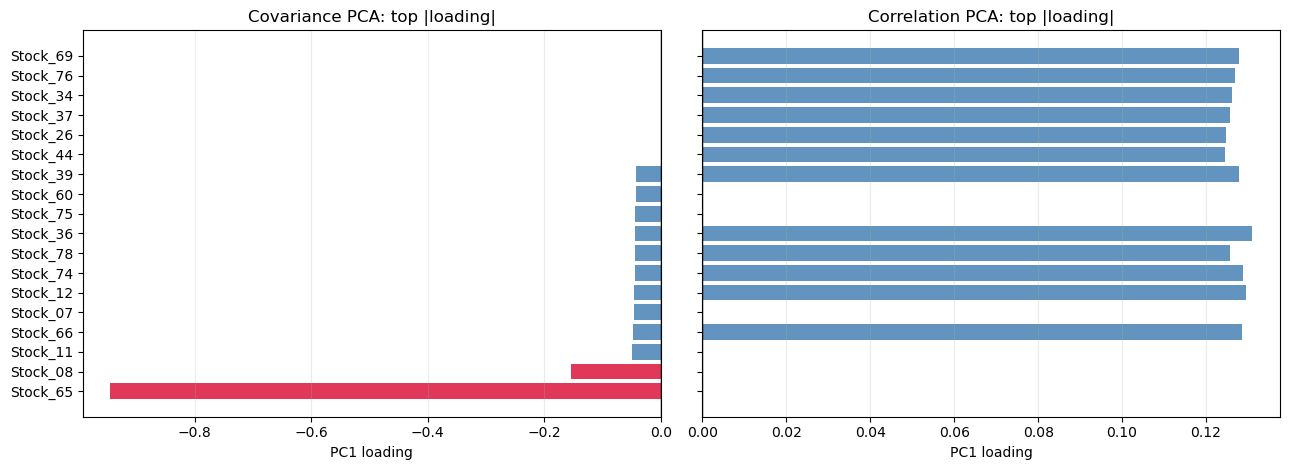

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

for ax, table, title in [
    (axes[0], cov_top.sort_values("pc1_loading"), "Covariance PCA: top |loading|"),
    (axes[1], corr_top.sort_values("pc1_loading"), "Correlation PCA: top |loading|"),
]:
    colors = np.where(table["is_huge_vol"], "crimson", "steelblue")
    ax.barh(table["stock"], table["pc1_loading"], color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("PC1 loading")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()


## Experiment 3: Repeated Trials

Now we repeat the simulation many times while keeping $\beta_i$ and $\sigma_i$ fixed.

Across trials, only $f_t$ and $\epsilon_{ti}$ are resampled.

We record:

1. alignment with the correct population direction;
2. correlation between $|\mathrm{PC1 loading}|$ and $\sigma_i$;
3. effective number of stocks contributing to PC1:

$$
N_{\mathrm{eff}}=\frac{1}{\sum_i v_i^4}.
$$

The fourth power appears because $p_i=v_i^2$ is the loading-mass share, and $\sum_i p_i^2=\sum_i v_i^4$ is a Herfindahl concentration index.


In [26]:
records = []
trial_rng = np.random.default_rng(999)

for trial in range(n_trials):
    R = simulate_returns(trial_rng)
    X, _ = standardize_columns(R)

    C_cov = sample_covariance(R, center=True)
    C_corr = X.T @ X / T

    vals_cov, vecs_cov = top_eigenpair(C_cov)
    vals_corr, vecs_corr = top_eigenpair(C_corr)

    for method, vals, vecs, true_dir in [
        ("Covariance PCA", vals_cov, vecs_cov, beta_dir),
        ("Correlation PCA", vals_corr, vecs_corr, gamma_dir),
    ]:
        v = vecs[:, 0]
        records.append({
            "trial": trial,
            "method": method,
            "lambda_1": vals[0],
            "alignment": align(v, true_dir),
            "corr_abs_loading_with_sigma": np.corrcoef(np.abs(v), sigma)[0, 1],
            "N_eff": effective_number(v),
        })

results = pd.DataFrame(records)
results.groupby("method")[["alignment", "corr_abs_loading_with_sigma", "N_eff"]].agg(["mean", "std"])


alignment           corr_abs_loading_with_sigma            \
                     mean       std                        mean       std   
method                                                                      
Correlation PCA  0.999907  0.000028                   -0.883453  0.008922   
Covariance PCA   0.426387  0.077120                    0.740259  0.061505   

                     N_eff            
                      mean       std  
method                                
Correlation PCA  74.643446  0.155819  
Covariance PCA    1.366496  0.303601

/var/folders/rc/yd72sc2j7b90m565yndg0tr80000gn/T/ipykernel_20007/2565129019.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=list(colors.keys()), patch_artist=True, showmeans=True, meanline=True)
/var/folders/rc/yd72sc2j7b90m565yndg0tr80000gn/T/ipykernel_20007/2565129019.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=list(colors.keys()), patch_artist=True, showmeans=True, meanline=True)
/var/folders/rc/yd72sc2j7b90m565yndg0tr80000gn/T/ipykernel_20007/2565129019.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=list(c

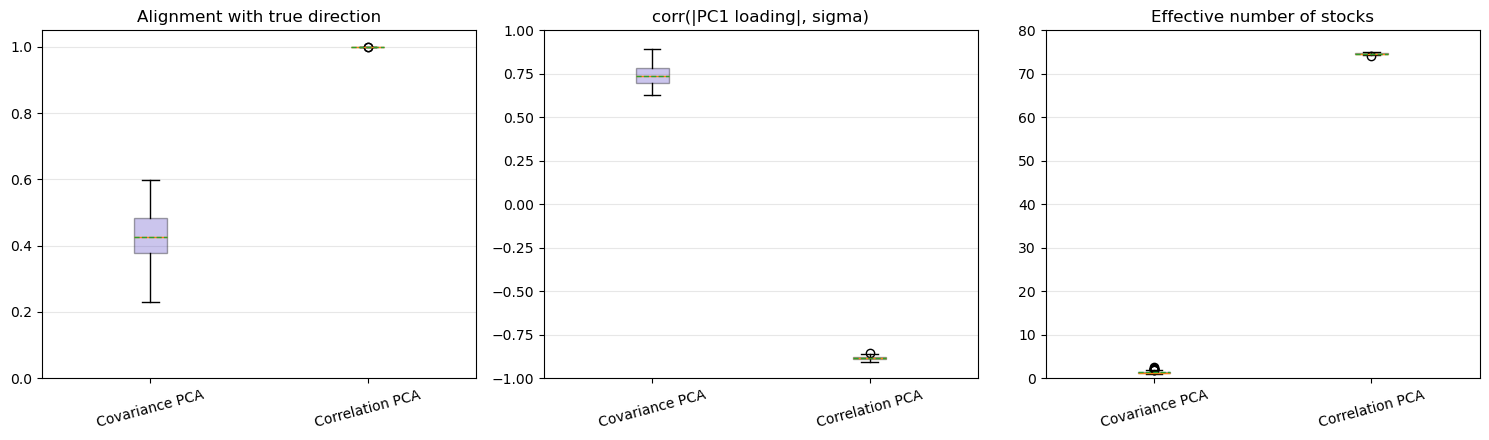

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = [
    ("alignment", "Alignment with true direction", (0, 1.05)),
    ("corr_abs_loading_with_sigma", "corr(|PC1 loading|, sigma)", (-1, 1)),
    ("N_eff", "Effective number of stocks", (0, N)),
]
colors = {"Covariance PCA": "slateblue", "Correlation PCA": "seagreen"}

for ax, (metric, title, ylim) in zip(axes, metrics):
    data = [results.loc[results["method"] == method, metric] for method in colors]
    box = ax.boxplot(data, labels=list(colors.keys()), patch_artist=True, showmeans=True, meanline=True)
    for patch, color in zip(box["boxes"], colors.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
    ax.set_title(title)
    ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


## Interpretation

This synthetic experiment separates two effects:

- a common factor exposure $\beta_i$;
- individual idiosyncratic volatility $\sigma_i$.

Covariance PCA maximizes absolute return variance, so a few extremely volatile assets can dominate PC1. This usually appears as:

- larger correlation between $|v_i|$ and $\sigma_i$;
- smaller $N_{\mathrm{eff}}$;
- top loadings concentrated in the huge-volatility stocks.

Correlation PCA standardizes each asset first. It is therefore less sensitive to raw volatility scale and is better aligned with the study of co-movement structure.

This is why, for random-matrix diagnostics on equity returns, we often begin with standardized returns and the correlation matrix rather than the raw covariance matrix.
